# Playbook

# ## Land Cover Classification with Random Forest



## Cell 1: Setup and Imports

In [5]:
# %% [markdown]
# # Land Cover Classification with Random Forest
#
# **Objective**: Classify aerial imagery into 5 land cover classes:
# - Trees
# - Other Vegetation
# - Cars
# - Buildings
# - Other Sealed Areas
#
# **Workflow**:
# 1. Load and preprocess the image.
# 2. Sample pixels interactively or use synthetic labels.
# 3. Train a Random Forest classifier.
# 4. Predict and visualize the classification.
# 5. Export the result as a GeoTIFF.

# %%
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import os

# Enable interactive mode for matplotlib
%matplotlib widget

# ----------------------------
# Configuration
# ----------------------------
# Input/Output paths (Windows-style)
image_path = r"D:/tasks/t01_playground/aerial_images_lux/aerial_aoi_lux_2023.tif"
output_dir = r"D:\tasks\t01_playground\tmp_results"
output_path = os.path.join(output_dir, "classified_land_cover.tif")

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Class definitions
CLASS_NAMES = {
    0: "Trees",
    1: "Other Vegetation",
    2: "Cars",
    3: "Buildings",
    4: "Other Sealed Areas"
}

## Cell 2: Load and Preprocess Image

In [6]:
# %% [markdown]
# ## Step 1: Load and Preprocess Image

# %%
# Load the image
try:
    with rasterio.open(image_path) as src:
        img = src.read()  # Shape: (bands, height, width)
        profile = src.profile  # Metadata (CRS, transform, etc.)
        print(f"Image loaded: {img.shape} (bands, height, width)")
except FileNotFoundError:
    raise FileNotFoundError(f"Image not found at: {image_path}")

# Reshape for sklearn (pixels x bands)
height, width = img.shape[1], img.shape[2]
img_reshaped = img.transpose(1, 2, 0).reshape(-1, img.shape[0])  # Shape: (height*width, bands)

Image loaded: (3, 2000, 3200) (bands, height, width)


## Cell 4: Generate Synthetic Labels (Fallback)

In [8]:
# %% [markdown]
# ## Step 3: Generate Synthetic Labels (Fallback)
#
# If no pixels were sampled interactively, use synthetic labels for training.

# %%
# Initialize variables if they don't exist (e.g., if Cell 3 was skipped)
if 'sampled_pixels' not in locals() or len(sampled_pixels) == 0:
    # Generate synthetic training data
    n_samples = 1000
    np.random.seed(42)
    sample_indices = np.random.choice(len(img_reshaped), n_samples, replace=False)
    samples = img_reshaped[sample_indices]

    # Assume band order: [NIR, Red, Green]
    nir = samples[:, 0]
    red = samples[:, 1]
    green = samples[:, 2]

    # Calculate NDVI and brightness for labeling
    ndvi = (nir - red) / (nir + red + 1e-10)
    brightness = np.mean(samples, axis=1)

    # Assign synthetic labels (ensure all 5 classes are represented)
    labels = np.zeros(n_samples, dtype=int)
    labels[(ndvi > 0.5) & (brightness < 150)] = 0  # Trees
    labels[(ndvi > 0.2) & (ndvi <= 0.5) & (brightness < 150)] = 1  # Other Vegetation
    labels[(ndvi < 0.1) & (brightness < 100)] = 2  # Cars
    labels[(ndvi < 0.2) & (brightness > 150)] = 3  # Buildings
    labels[(ndvi < 0.2) & (brightness <= 150) & (brightness >= 100)] = 4  # Other Sealed Areas

    # Use synthetic samples and labels
    samples = samples
    print("Using synthetic labels for training (no pixels were sampled interactively).")
else:
    # Use manually sampled pixels
    samples = sampled_pixels
    # If labels were not assigned in Cell 3, prompt for them now
    if 'labels' not in locals():
        labels = []
        for coord in sampled_coords:
            y, x = coord
            class_label = int(input(f"Enter class (0-4) for pixel at ({x}, {y}): "))
            while class_label not in CLASS_NAMES:
                class_label = int(input("Invalid class. Enter 0-4: "))
            labels.append(class_label)
        labels = np.array(labels)
    print(f"Using {len(samples)} manually sampled pixels for training.")

Using synthetic labels for training (no pixels were sampled interactively).


## Cell 5: Train Random Forest Classifier

In [9]:
# %% [markdown]
# ## Step 4: Train Random Forest Classifier

# %%
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    samples, labels, test_size=0.3, random_state=42
)

# Train the classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate on test set
y_pred = clf.predict(X_test)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES.values(),
    labels=[0, 1, 2, 3, 4]  # Explicitly list all 5 classes
))


Classification Report:
                    precision    recall  f1-score   support

             Trees       0.95      0.86      0.90       180
  Other Vegetation       0.89      0.50      0.64        16
              Cars       1.00      0.50      0.67         2
         Buildings       0.79      0.99      0.88        87
Other Sealed Areas       0.78      0.93      0.85        15

          accuracy                           0.88       300
         macro avg       0.88      0.76      0.79       300
      weighted avg       0.89      0.88      0.88       300



## Cell 6: Predict and Visualize Classification

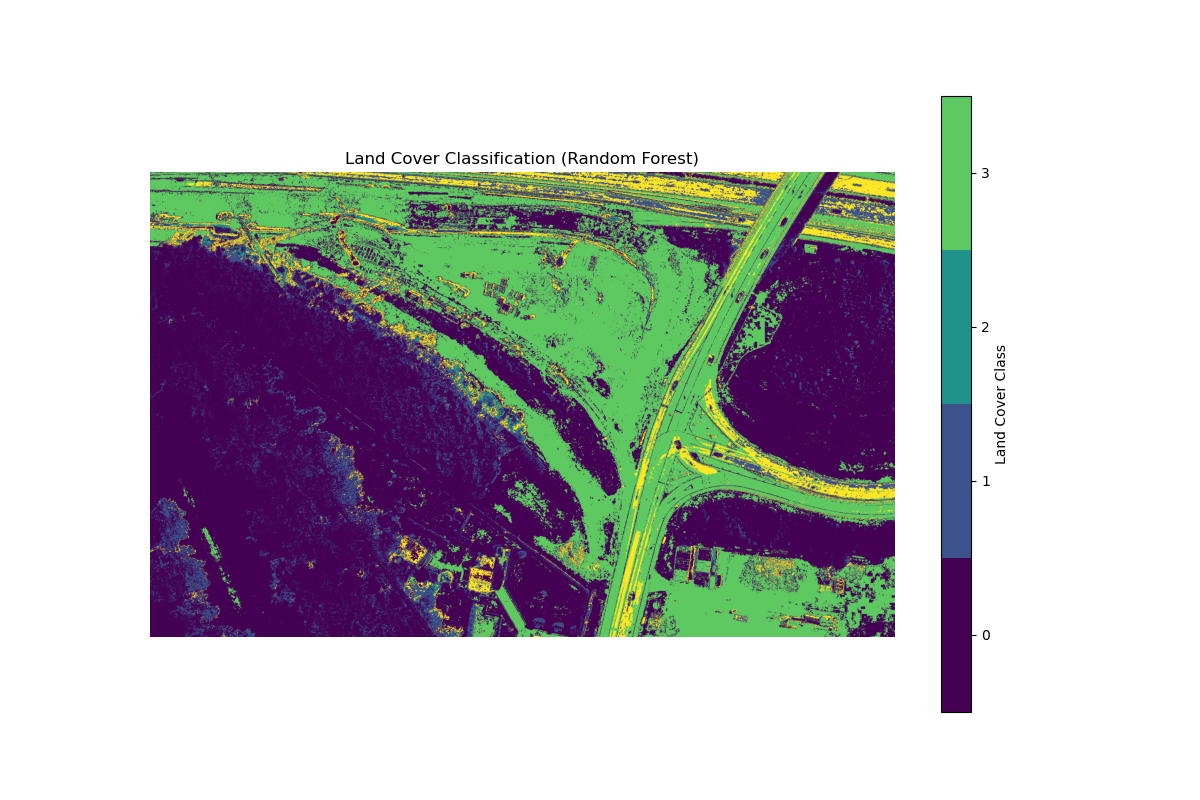

In [10]:
# %% [markdown]
# ## Step 5: Predict and Visualize Classification

# %%
# Predict for the entire image
prediction = clf.predict(img_reshaped)
classified_img = prediction.reshape(height, width)

# Visualize the classified map
plt.figure(figsize=(12, 8))
plt.imshow(classified_img, cmap="viridis", vmin=0, vmax=4)
plt.colorbar(
    ticks=[0, 1, 2, 3, 4],
    label="Land Cover Class",
    boundaries=np.arange(5) - 0.5
)
plt.title("Land Cover Classification (Random Forest)")
plt.axis("off")
plt.show()

## Cell 7: Export Classified Image as GeoTIFF

In [11]:
# %% [markdown]
# ## Step 6: Export Classified Image as GeoTIFF

# %%
# Update profile for single-band output
profile.update(
    dtype=rasterio.uint8,
    count=1,
    nodata=255  # Optional: Set nodata value
)

# Write to file
with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(classified_img.astype(rasterio.uint8), 1)

print(f"\nClassified image saved to: {output_path}")


Classified image saved to: D:\tasks\t01_playground\tmp_results\classified_land_cover.tif


## Cell 8: Class Distribution Summary

In [12]:
# %% [markdown]
# ## Step 7: Class Distribution Summary

# %%
from collections import Counter

# Count class occurrences
class_counts = Counter(prediction)
total_pixels = len(prediction)

# Create a summary table
print("\nClass Distribution in Final Classification:")
print("-------------------------------------------")
for class_id, count in sorted(class_counts.items()):
    percentage = (count / total_pixels) * 100
    print(f"{CLASS_NAMES[class_id]:<20}: {count:>8} pixels ({percentage:>6.2f}%)")


Class Distribution in Final Classification:
-------------------------------------------
Trees               :  3495029 pixels ( 54.61%)
Other Vegetation    :   459409 pixels (  7.18%)
Cars                :    46425 pixels (  0.73%)
Buildings           :  2009375 pixels ( 31.40%)
Other Sealed Areas  :   389762 pixels (  6.09%)
